In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import glob
import random

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

np.random.seed(3)

Using device: cuda


In [2]:
def show_mask(mask, ax, random_color=False, borders=True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

In [3]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# Load SAM2 model
sam2_checkpoint = "sam_checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)
predictor = SAM2ImagePredictor(sam2_model)

print("SAM2 model loaded successfully!")

SAM2 model loaded successfully!


In [4]:
def load_dataset(data_dir):
    """Load dataset from all country directories"""
    dataset = []
    country_dirs = [d for d in os.listdir(data_dir) if d.startswith('country_')]
    
    for country_dir in country_dirs:
        country_path = os.path.join(data_dir, country_dir)
        images_path = os.path.join(country_path, 'images')
        labels_path = os.path.join(country_path, 'labels')
        
        image_files = glob.glob(os.path.join(images_path, '*.jpg'))
        
        for image_file in image_files:
            base_name = os.path.splitext(os.path.basename(image_file))[0]
            label_file = os.path.join(labels_path, f"{base_name}.txt")
            
            if os.path.exists(label_file):
                bboxes = []
                with open(label_file, 'r') as f:
                    for line in f:
                        line = line.strip()
                        if line:
                            parts = line.split()
                            if len(parts) == 5:
                                class_id = int(parts[0])
                                x_center = float(parts[1])
                                y_center = float(parts[2])
                                width = float(parts[3])
                                height = float(parts[4])
                                bboxes.append({
                                    'class_id': class_id,
                                    'x_center': x_center,
                                    'y_center': y_center,
                                    'width': width,
                                    'height': height,
                                })
                
                dataset.append({
                    'image_path': image_file,
                    'label_path': label_file,
                    'bboxes': bboxes,
                    'country': country_dir
                })
    
    return dataset

# Load dataset
data_dir = "data"
dataset = load_dataset(data_dir)
samples_with_bboxes = [sample for sample in dataset if len(sample['bboxes']) > 0]

print(f"Total samples: {len(dataset)}")
print(f"Samples with bounding boxes: {len(samples_with_bboxes)}")

Total samples: 6039
Samples with bounding boxes: 6039


In [9]:
def segment_road_image(image_path, predictor):
    """
    Apply SAM segmentation to road image with optimized point selection
    Point is placed at 5/8 height from top and 1/2 width from left (road center)
    """
    # Load image
    image = Image.open(image_path)
    image = np.array(image.convert("RGB"))
    
    # Set image for predictor
    predictor.set_image(image)
    
    # Get image dimensions
    h, w = image.shape[:2]
    
    # Modified point selection: 5/8 from top, 1/2 from left
    input_point = np.array([[w // 2, int(h * 7/8)]])
    input_label = np.array([1])
    
    # Get predictions
    masks, scores, logits = predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True,
    )
    
    # Sort by score (highest first)
    sorted_ind = np.argsort(scores)[::-1]
    masks = masks[sorted_ind]
    scores = scores[sorted_ind]
    
    return image, masks, scores, input_point, input_label

def plot_best_segmentation(image, masks, scores, input_point, input_label, sample_info):
    """Plot original image and the most confident segmentation result"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Original image with point
    axes[0].imshow(image)
    show_points(input_point, input_label, axes[0])
    axes[0].set_title(f"Original Image\n{os.path.basename(sample_info['image_path'])}")
    axes[0].axis('off')
    
    # Best segmentation mask
    axes[1].imshow(image)
    show_mask(masks[0], axes[1], borders=True)
    show_points(input_point, input_label, axes[1])
    axes[1].set_title(f"Best Segmentation\nConfidence: {scores[0]:.3f}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return scores[0]  # Return confidence score

Processing road segmentation on sample images...
Point selection: 3/4 height from top, 1/2 width from left

Sample 1/5: country2_002947.jpg
Country: country_2, Damage instances: 2


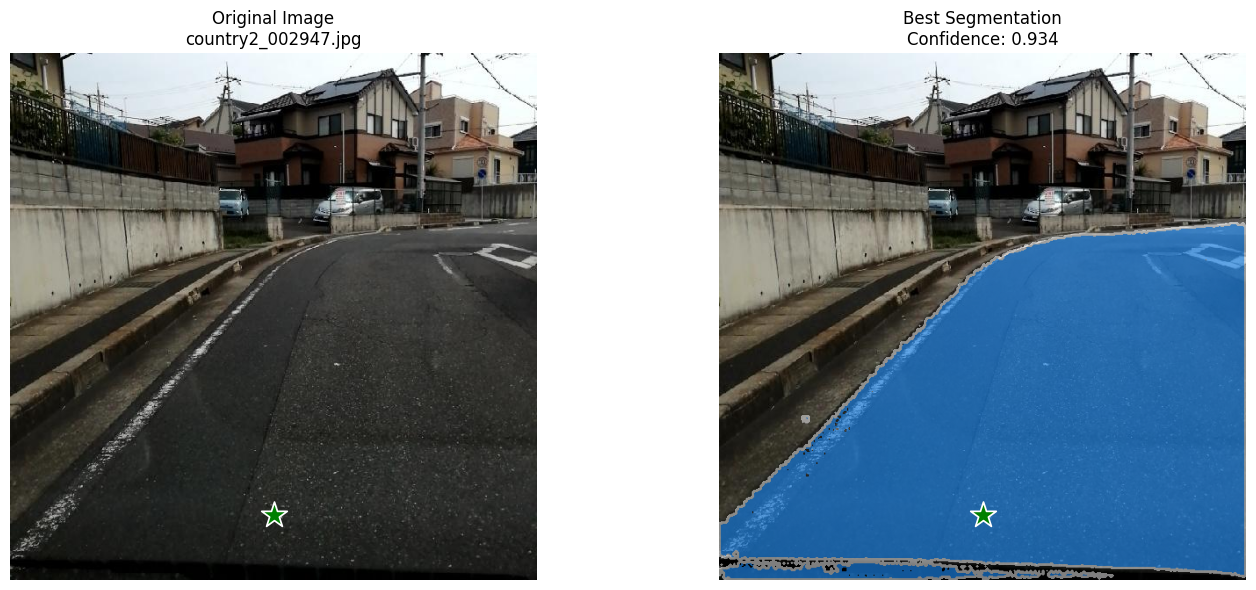

Segmentation confidence: 0.934

Sample 2/5: country3_002477.jpg
Country: country_3, Damage instances: 3


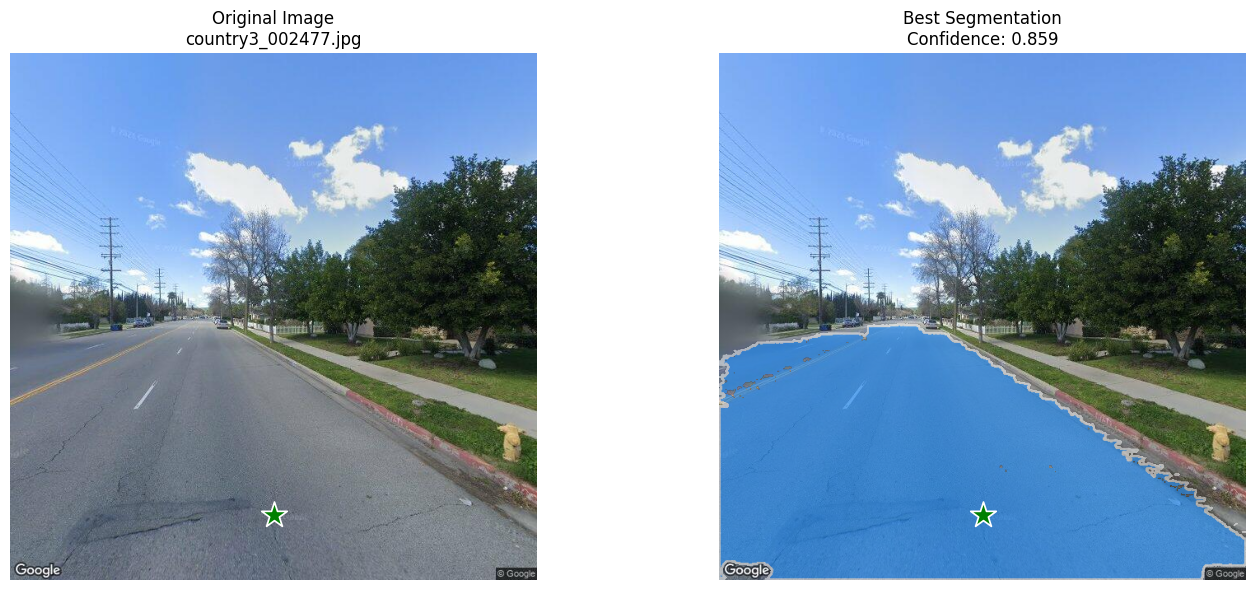

Segmentation confidence: 0.859

Sample 3/5: country2_001078.jpg
Country: country_2, Damage instances: 7


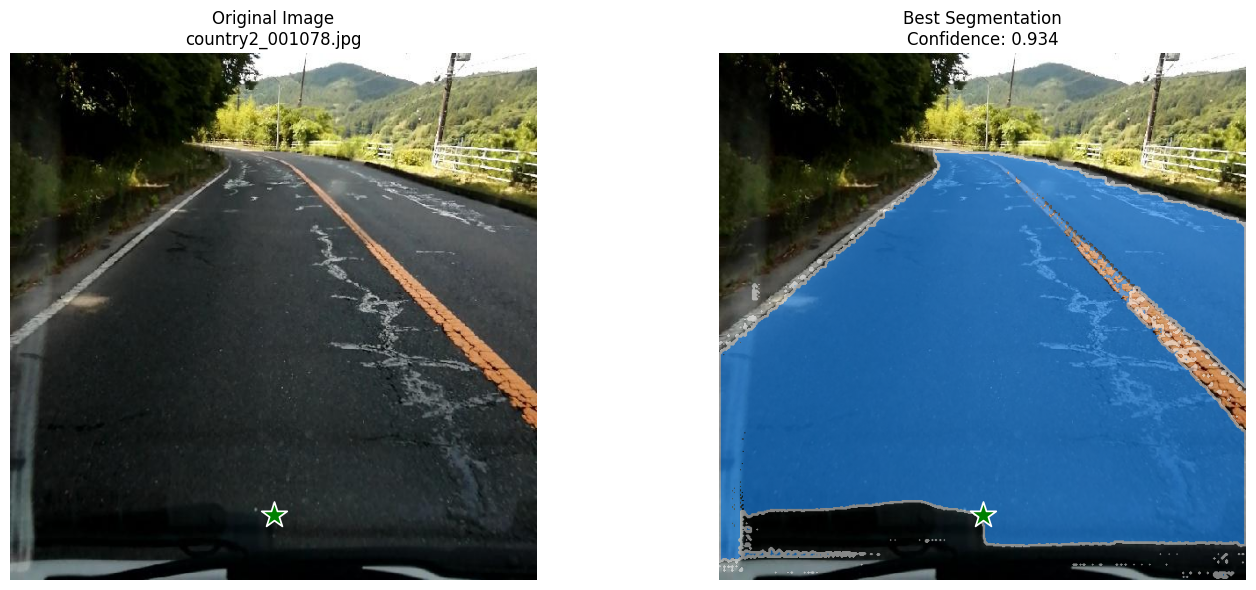

Segmentation confidence: 0.934

Sample 4/5: country3_001570.jpg
Country: country_3, Damage instances: 1


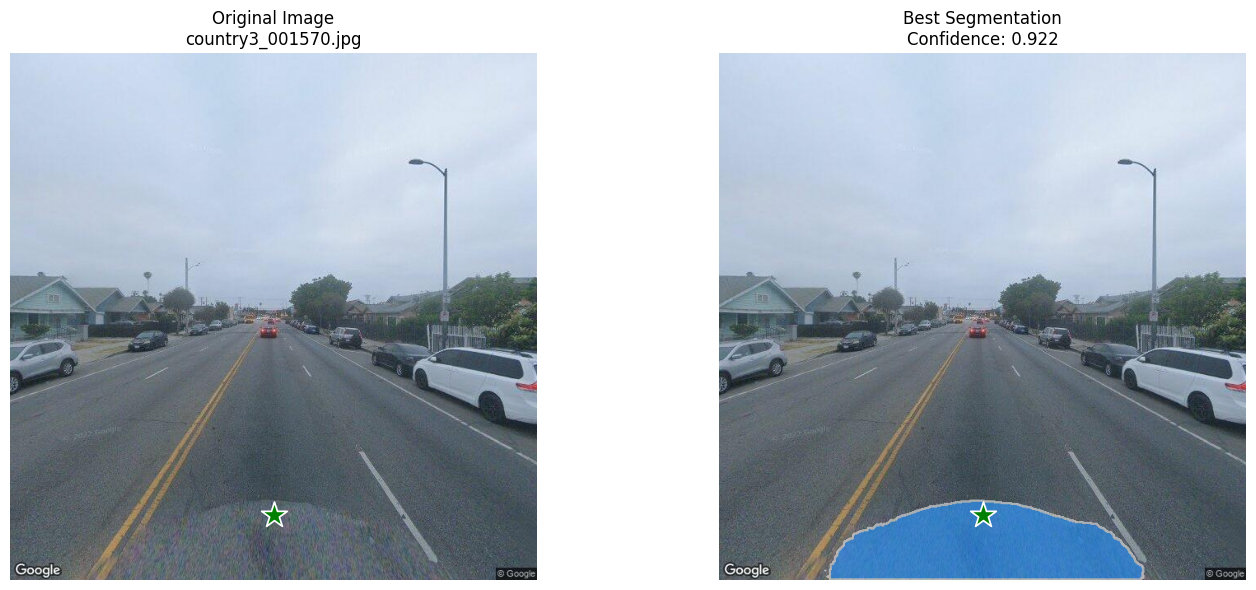

Segmentation confidence: 0.922

Sample 5/5: country3_000839.jpg
Country: country_3, Damage instances: 3


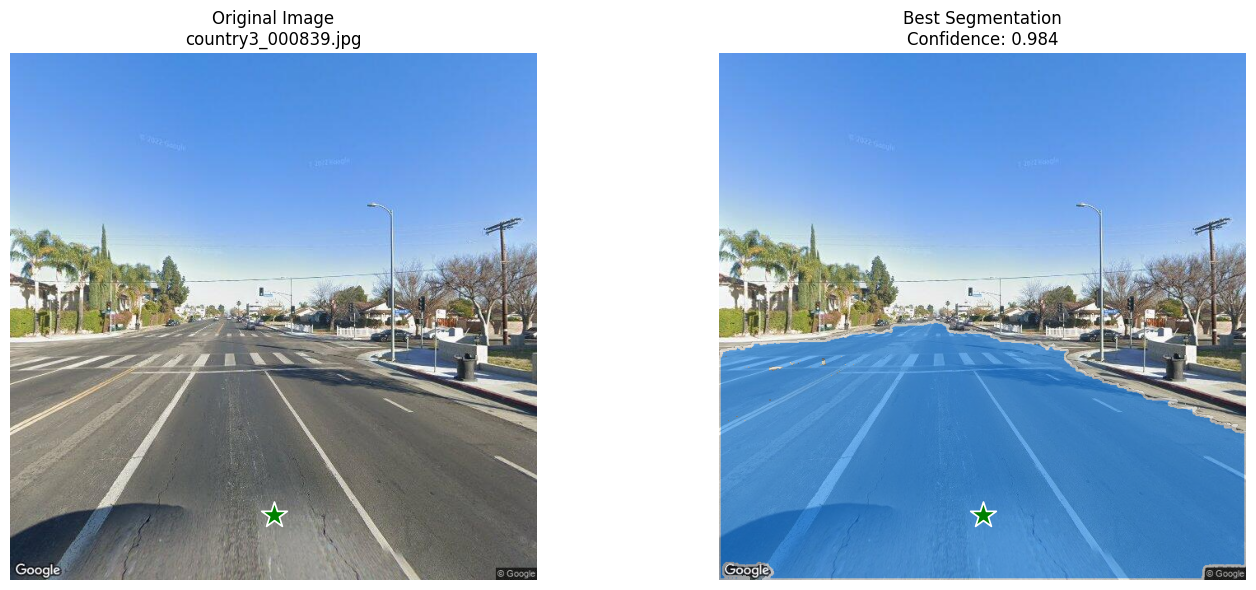

Segmentation confidence: 0.984

Average segmentation confidence: 0.927
Confidence range: 0.859 - 0.984


In [10]:
# Sample and process images
n_samples = 5
random_samples = random.sample(samples_with_bboxes, min(n_samples, len(samples_with_bboxes)))

print("Processing road segmentation on sample images...")
print("Point selection: 3/4 height from top, 1/2 width from left")
print("=" * 60)

confidence_scores = []

for i, sample in enumerate(random_samples):
    print(f"\nSample {i+1}/{len(random_samples)}: {os.path.basename(sample['image_path'])}")
    print(f"Country: {sample['country']}, Damage instances: {len(sample['bboxes'])}")
    
    try:
        # Apply segmentation
        image, masks, scores, input_point, input_label = segment_road_image(
            sample['image_path'], predictor
        )
        
        # Plot results
        confidence = plot_best_segmentation(image, masks, scores, input_point, input_label, sample)
        confidence_scores.append(confidence)
        
        print(f"Segmentation confidence: {confidence:.3f}")
        
    except Exception as e:
        print(f"Error processing {sample['image_path']}: {e}")

print(f"\nAverage segmentation confidence: {np.mean(confidence_scores):.3f}")
print(f"Confidence range: {np.min(confidence_scores):.3f} - {np.max(confidence_scores):.3f}")

# Summary

This streamlined SAM segmentation notebook focuses on the essential components:

## Key Features:
1. **Optimized Point Selection**: Uses 5/8 height from top and 1/2 width from left for road-focused segmentation
2. **Dataset Loading**: Efficiently loads images and bounding box annotations from all country datasets
3. **Confidence-Based Results**: Shows only the most confident segmentation mask for each image
4. **Performance Metrics**: Tracks average confidence scores across samples

## Point Selection Rationale:
- **5/8 height from top**: Captures the road surface area where damage typically occurs
- **1/2 width from left**: Centers on the road to avoid roadside objects
- This positioning works well for typical road imagery perspectives

## Results:
The segmentation focuses on road surface areas, providing a good foundation for:
- Road damage detection
- Surface area analysis
- Integration with YOLO bounding box predictions